In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    # b_std = 'b' + str(i) + '_std'
    # b_name.append(b_std)


b_name = np.array(b_name)
# b_name

In [4]:
x_RDMC = np.array(df_svc_RDMC[b_name])
x_SRL = np.array(df_svc_SRL[b_name])
x_RTD = np.array(df_svc_RTD[b_name])
x_RD = np.array(df_svc_RD[b_name])
x_SRA = np.array(df_svc_SRA[b_name])
x_RBD = np.array(df_svc_RBD[b_name])
x_RLD = np.array(df_svc_RLD[b_name])
x_RD13C = np.array(df_svc_RD13C[b_name])
x_RNC = np.array(df_svc_RNC[b_name])
x_RD15N = np.array(df_svc_RD15N[b_name])
x_RCN = np.array(df_svc_RCN[b_name])
x_RCC = np.array(df_svc_RCC[b_name])

In [5]:
df_svc_RCN

,site,RDMC_A,SRL,RTD,RD,SRA,RBD,RLD,RCC,Rd13C,...,b113_std,b114_std,b115_std,b116_std,b117_std,b118_std,b119_std,b120_std,b121_std,b122_std
0,S2A_Q03,336.738703,NaN,NaN,NaN,NaN,0.002622,NaN,423.179198,-28.593295,...,0.094636,0.091016,0.086453,0.083884,0.081630,0.085008,0.086160,0.081314,0.091264,0.088878
1,S2A_Q04,353.271028,NaN,NaN,NaN,NaN,0.002062,NaN,456.907537,-28.606056,...,0.093358,0.098814,0.095093,0.087949,0.090643,0.087814,0.093128,0.091050,0.084613,0.094102
2,S2A_Q05,175.438596,NaN,NaN,NaN,NaN,0.003750,NaN,457.454297,-27.445805,...,0.098341,0.103587,0.095742,0.097895,0.100804,0.095598,0.097233,0.100876,0.098988,0.104726
3,S2A_Q07,596.412556,40.710812,0.343669,0.301668,385.201504,0.001307,2.671432,466.883585,-28.566239,...,0.052298,0.048208,0.040412,0.042356,0.045369,0.039786,0.044814,0.039904,0.046098,0.064107
4,S2A_Q08,372.549020,96.196211,0.253333,0.228576,692.194737,0.000355,0.901767,439.500101,-28.717293,...,0.050990,0.058351,0.054249,0.053797,0.056926,0.054287,0.056676,0.060053,0.056563,0.063500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,S7_Q20,257.772601,136.121754,0.584422,0.126511,541.220120,0.004291,6.942844,424.600000,-28.292000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
127,S7_Q21,263.733144,190.151161,0.504828,0.115169,687.338798,0.003750,6.104361,411.490000,-27.654000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
128,S7_Q22,224.401607,193.358806,0.440957,0.122201,741.851628,0.006126,9.586216,436.110000,-28.360000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877
129,S7_Q23,212.132938,165.517248,0.620833,0.111313,578.797315,0.008013,16.223739,432.800000,-28.113000,...,0.097995,0.098650,0.099334,0.099691,0.099581,0.099521,0.099277,0.098445,0.097944,0.096877


In [6]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [7]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [8]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [9]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [10]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [11]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


KeyboardInterrupt



[216.11883002 176.09324316 307.8958269  282.69770301 293.86557448
 281.17834495 236.05924741 228.373161   177.19658046 239.7556253
 230.6531901  256.7074539  270.77336429 249.0173566  337.61482125
 219.27346371 235.75297921 313.63802996 201.9988202  321.45361846
 287.37803185 217.4320556  395.13389631 226.26740282 243.67009489
 292.01605167 353.26879253 344.97455953 353.75763656 295.57280194
 279.48224519 404.24796457 301.00152839 404.43404106 375.16504257
 340.75703192 356.93702406 258.64229376 303.76230644 346.24841602
 354.30420647 336.74741319 304.11727035 314.80599064 325.86764189
 316.68393    306.06875842 325.80653426 369.24469659 328.326808
 294.173799   312.41287859 347.32242017 318.34229582 338.6644234
 307.79866282 350.23239613 320.18416158 322.36421641 323.12364927
 311.5128853  305.07541934 282.59680544 324.26360198 316.48559881
 333.11165177 327.25883077 330.40704992 315.79558265 306.61998915
 277.85579324 335.49659512 314.50675272 321.38693584 334.48792577
 341.31539903 

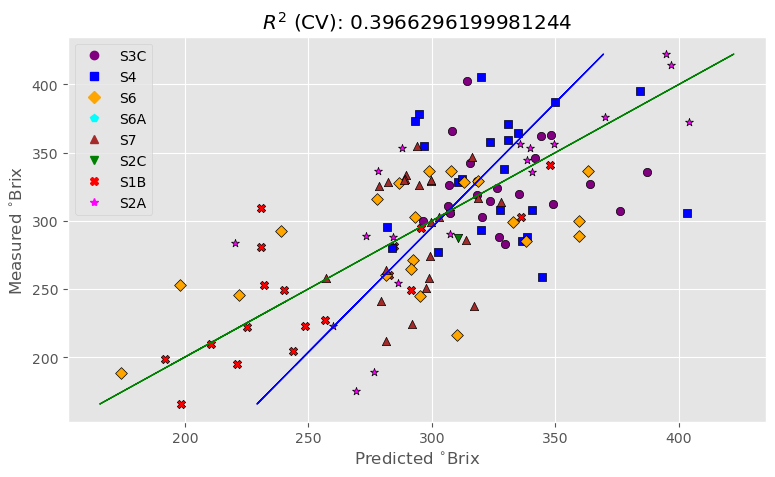

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)


## SRL

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  16
Wavelengths to be kept  20
Optimised MSEP  32.1115455490082



[112.37865174  97.39210325 105.82306691  89.52585894 118.06265812
 119.77703432 122.19517236 142.00164204  99.57255648 101.02515039
 117.53764707 117.16618292 102.2907158  126.53126668 108.78892453
 128.22725846 140.52274071  93.84380594 106.26305946  53.0583361
  76.7590339   73.95859948  74.93859096  26.58726591  82.97290119
  41.71737986  51.09017803  51.19404164  63.35663724  -8.78557526
  18.8133968   48.03585926  25.91659832  85.14646382  37.33012406
  43.34224677  97.8716376  132.86854352 104.53095978 116.70999031
 127.72617518 147.00628969 132.8185108  129.94127906 117.70098853
 143.7348504  177.84220468 135.10610584 144.79764123 128.35433218
 132.76160107 128.83943384 119.54062212 124.64610631 144.51480139
 126.44458891 139.78533611 114.47174475 133.29736525 173.93583589
 146.00055481 120.31770317 123.90623544 130.91081489 130.07980249
 126.64154134 121.9037914  128.3945882  160.5070129  111.88277799
 152.90959395 140.71418945 125.80892835 155.91625205 156.15245956
 136.009540

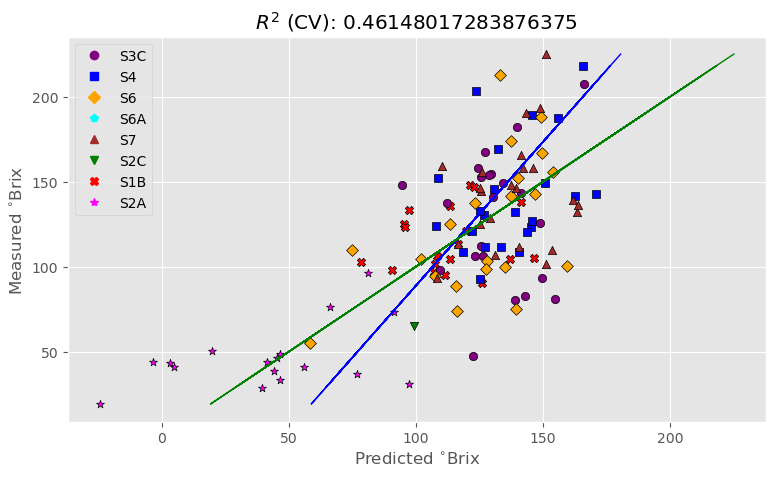

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

## RTD
 

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  23
Wavelengths to be kept  30
Optimised MSEP  0.07427776190485622



[0.35747079 0.24341391 0.21846319 0.45009789 0.44549565 0.46027504
 0.43144313 0.37173409 0.43135524 0.41251935 0.47482599 0.45634138
 0.56981469 0.39627781 0.57722533 0.47476547 0.44573337 0.44373447
 0.49854154 0.35300562 0.32399406 0.34693292 0.59123092 0.56427979
 0.56740779 0.48014388 0.59715954 0.48903055 0.53704071 0.48001349
 0.48087688 0.63448495 0.51986635 0.36735733 0.59954141 0.69823772
 0.2961978  0.47551831 0.57427381 0.54201509 0.49026903 0.48391
 0.47487438 0.54708561 0.46409868 0.45384599 0.44716394 0.38419813
 0.45586847 0.49061067 0.41879838 0.46848971 0.50781027 0.46719106
 0.45139018 0.51615626 0.48280634 0.41451863 0.48785608 0.51543629
 0.51070032 0.57308146 0.52212308 0.55299418 0.58831547 0.49296407
 0.41924858 0.54780567 0.48255727 0.52744649 0.5569534  0.39976682
 0.49063715 0.52160402 0.51396635 0.5135355  0.50886011 0.50395166
 0.54676282 0.58968463 0.57222716 0.49078615 0.42889908 0.46442285
 0.44218251 0.44915186 0.38411062 0.47792826 0.49593439 0.5000068

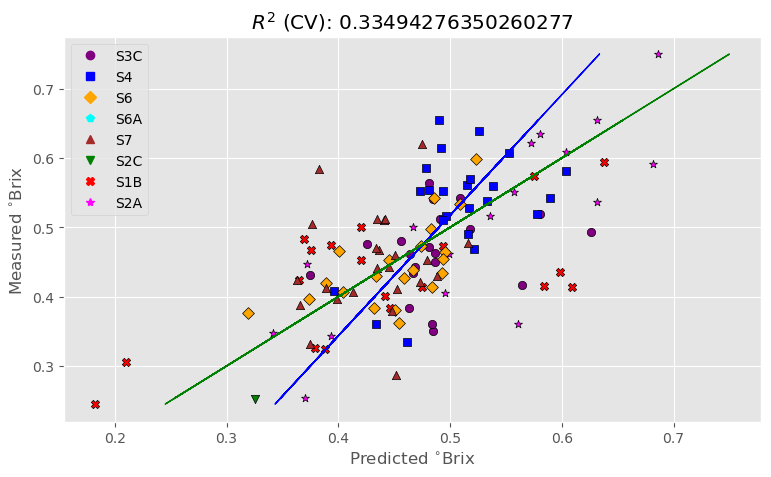

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [20]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  17
Wavelengths to be kept  35
Optimised MSEP  0.029923477027560017



[0.14505645 0.13071539 0.13051536 0.11907716 0.14290254 0.1590655
 0.12393879 0.13946116 0.13589352 0.13395592 0.1399155  0.13855611
 0.13481801 0.12505234 0.14125959 0.15027607 0.1492419  0.12054628
 0.15624091 0.13959356 0.14504233 0.13596119 0.14402444 0.14458968
 0.15029643 0.13682019 0.12410438 0.15826127 0.16806973 0.13749753
 0.13647045 0.15425165 0.12211247 0.14408831 0.17719151 0.12862152
 0.13903372 0.13944266 0.13728562 0.14030293 0.15830385 0.14003917
 0.13960158 0.13772276 0.13602264 0.14738541 0.12881142 0.16069848
 0.13189111 0.15479122 0.14215122 0.14396628 0.14068893 0.14227318
 0.14186622 0.14234702 0.12799564 0.14036308 0.14711649 0.16039084
 0.13310213 0.14149222 0.15617057 0.13878693 0.16138848 0.16609105
 0.13354525 0.16564404 0.15901906 0.14821578 0.16324829 0.14840796
 0.15279771 0.14327662 0.13066004 0.20445432 0.15424538 0.15826103
 0.17357219 0.15377052 0.14827341 0.15842991 0.15215348 0.12550527
 0.14469966 0.16527122 0.15069994 0.16744162 0.1658536  0.13829

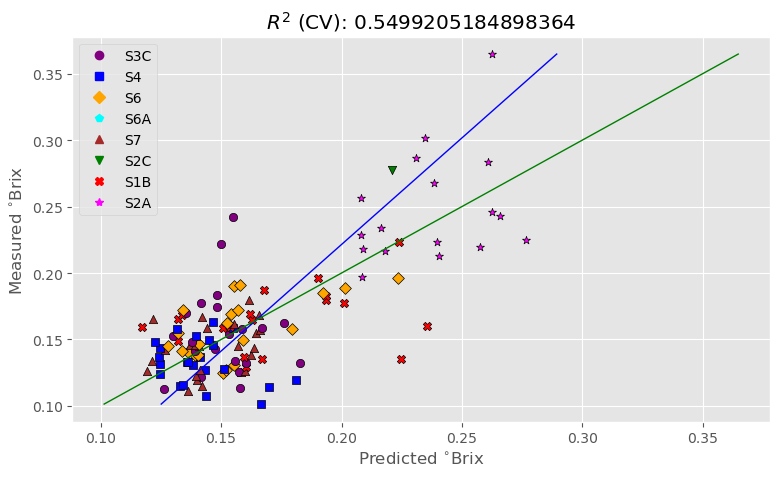

In [21]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  19
Wavelengths to be kept  27
Optimised MSEP  94.7837880163111



[562.98083111 783.97482465 751.12880613 490.48168515 564.20262369
 567.6117087  503.59599035 773.31782166 553.36026539 567.35898388
 569.67136145 464.33181755 465.90552597 546.81037877 494.0415237
 600.13760108 652.34088391 648.91086705 528.08157399 414.13234359
 535.78572042 477.30468109 305.78821447 303.88773305 427.57422914
 338.35131851 334.81680811 292.2970459  414.56191418 212.95010748
 383.91631155 335.8000244  313.54395913 443.17697133 256.65746812
 173.17674514 559.83525653 555.30954948 485.8198594  502.98058414
 551.05754008 575.78380703 581.19218711 529.82677784 580.17140817
 587.49688726 635.41226662 648.35853085 591.01072999 620.43154498
 564.90846947 591.5600949  567.03398451 585.14160456 590.96864455
 556.94242505 530.2527039  564.96776963 786.94562784 676.86432819
 555.31057319 567.35799461 532.06660355 545.82934626 560.91610922
 521.73817283 582.19891688 657.98405979 518.84101158 600.8041656
 556.98293882 516.81994511 660.3202529  629.54139928 537.47919161
 578.5957387

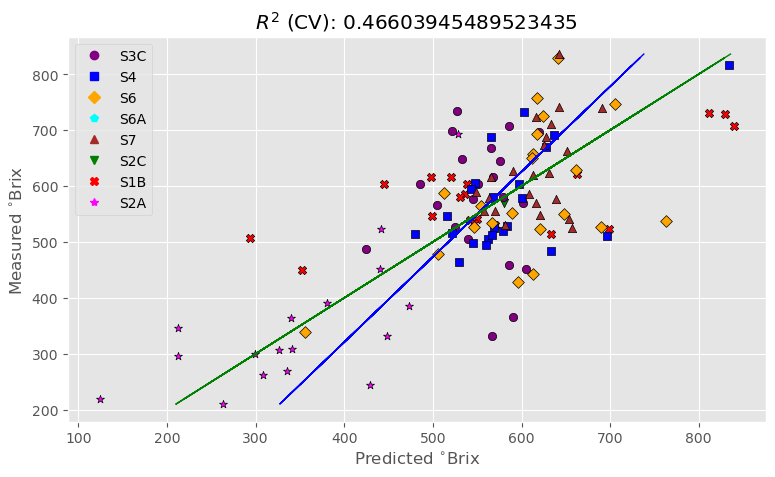

In [14]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 25)



Optimised number of PLS components:  22
Wavelengths to be kept  45
Optimised MSEP  0.003212709163585645



[ 6.69790266e-03  7.21979339e-03  4.89386593e-03  1.81675080e-02
  1.18636186e-02  9.59008248e-03  8.99408834e-03  3.99710841e-03
  1.19535074e-02  4.45555625e-03  3.58612990e-03  1.21213691e-02
  1.38976182e-02  9.10743590e-03  1.62550505e-02  3.44189727e-03
  2.81521432e-03  1.00472938e-02  4.17131091e-03  1.36935772e-03
  3.15247531e-03  2.07953329e-03  1.21027266e-03  2.83384405e-03
 -5.65130517e-04  1.93932715e-03  6.16704639e-03  4.94661065e-03
  5.38359886e-03  4.58977061e-04  5.81151213e-03  1.36050823e-02
  3.73269301e-03 -3.19078157e-04  1.44383595e-03  7.75123666e-03
  8.41170936e-03  9.12018584e-03  1.22808971e-02  8.41639638e-03
  4.31945774e-03  4.23040408e-03  5.44100472e-03  9.89654669e-03
  2.65397505e-03  4.36104240e-03  8.77314267e-03  4.57701369e-03
  3.77425330e-03  6.48774164e-03  6.16632036e-03  6.16880194e-03
  7.09008197e-03  3.54463601e-03  7.91586012e-03  6.23180537e-03
  3.04462468e-03  6.98340542e-03  3.72706761e-03  4.50916506e-03
  7.19991308e-03  8.64359

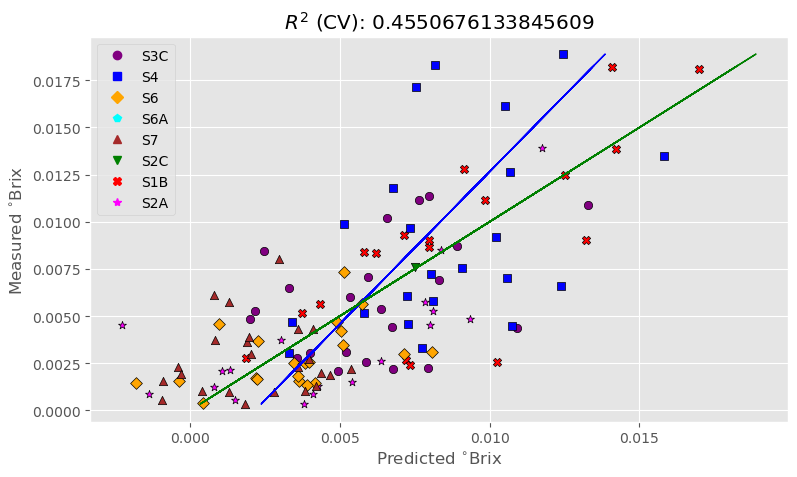

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  18
Wavelengths to be kept  45
Optimised MSEP  2.6734681402953338



[ 0.0685009   2.3017485   2.33158002  1.87187084 -1.02098648  1.91026635
  2.04698231  2.6031557   5.96169544  2.11715255  2.16598519  2.2450439
  6.74475516  2.33485317  2.05418894  1.40098774  1.56270132  4.17489068
  2.21892757  2.6666261   2.76539681  4.80409182  3.83570275  4.22918597
  3.45172795  2.21758934  6.17741318  2.85099805  6.95052923  3.1179655
  1.93774895  1.77997558  4.78579538  3.98425944  5.85123805  5.52334629
  5.78475396  3.11805366  4.89857911  3.63835602  3.7723707   4.53272449
  6.64295781  5.17832704  7.40656966  5.48976983  6.45573089  6.05969615
  5.67251526  3.86356268  3.8223994   5.7305384   7.20159854  6.99717002
  5.96859576  4.29452388  4.82562523  5.72311912  6.96966427  7.12487482
  3.87036124  5.84570254  5.11357604  6.40455106  6.14809668  5.25237013
  4.91975992  4.08594905  5.61207174  4.06467567  6.34219035  6.43629894
  5.65375268  8.01596363  8.3837742   6.48061526  7.13612121  6.03369104
  6.09403441  6.86580568  5.74559949  8.08965207  8.1

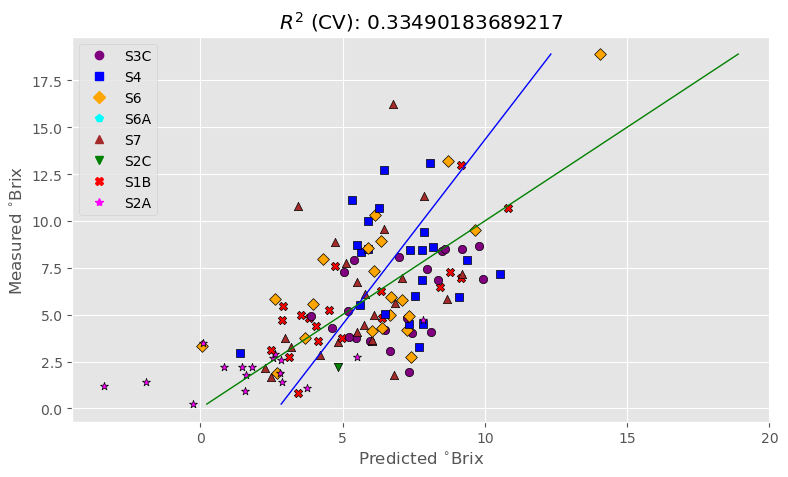

In [13]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [12]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  23
Wavelengths to be kept  34
Optimised MSEP  0.837058689332012



[-28.03902698 -28.65215511 -28.06448284 -28.27775435 -28.74336108
 -27.83805067 -28.49744485 -28.75974477 -28.73437924 -26.91467969
 -27.63650598 -29.06427127 -28.32900185 -27.89825802 -28.64737437
 -28.25322988 -27.70194492 -28.17644646 -28.32250378 -28.35029076
 -28.90369437 -26.83742641 -26.61664144 -27.25514772 -25.90264076
 -28.70073902 -28.16774285 -27.81366915 -28.70003156 -28.22112984
 -28.83662554 -27.79211003 -27.93213527 -26.24118322 -28.74944492
 -27.39850294 -28.24743748 -27.19146811 -29.44461252 -28.03107812
 -27.80896298 -26.64126126 -27.82410575 -26.20959336 -28.62450541
 -26.83978031 -28.2554635  -27.00396201 -28.19367943 -27.26615337
 -27.80174833 -28.08206682 -27.92670815 -27.90138346 -28.01473477
 -28.07675368 -27.35097331 -27.79745373 -27.39233934 -27.76535718
 -27.84705739 -27.51429983 -27.5983628  -27.69835439 -28.17434521
 -28.17786338 -28.66998839 -27.972048   -27.72782534 -28.27210568
 -28.22445483 -28.283963   -28.25156997 -27.35107914 -28.88090852
 -27.97086

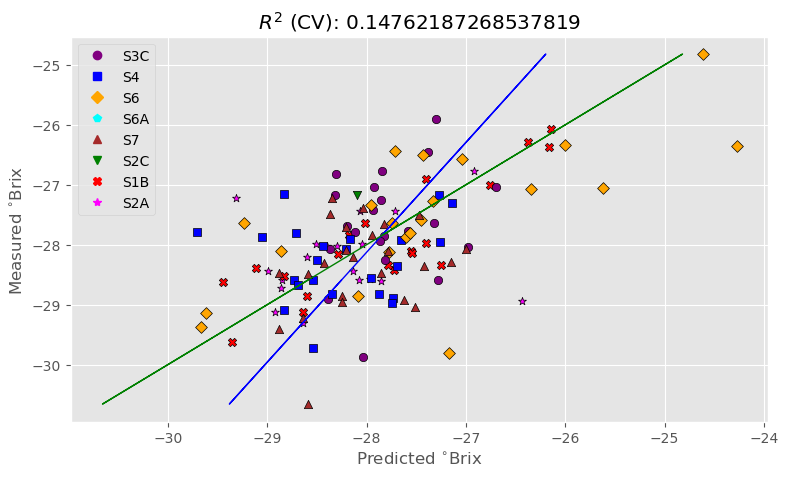

In [13]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  2
Wavelengths to be kept  42
Optimised MSEP  1.9238138512373673

[10.33249568  9.9448083   9.46914093  9.23459536  9.55060287 10.66761868
  9.7351188   9.65549846  9.48292717  9.30504937 10.06216789  9.82293323
 10.29102985  9.39041197 10.942669    8.89364278  9.10359673 10.86657237
  9.89007268  8.93305735  9.8835272   9.81082688  8.6748626   8.84295067
  8.74637914  9.77557638  9.5370821   9.54312472  9.67867782 10.9853288
 11.09737932  9.84344447 10.07460172 11.78255009  9.82800598 10.03449788
  9.83824371 10.1268268   9.83052305 11.17451155  9.82481997  9.15915861
  9.52586122  9.25536541 10.28215225 10.46065492 10.35274008 12.0462922
  9.46538522  8.92918552  9.81207515  8.74590085 10.05974003  9.05984084
  9.59333772  9.77682501  9.77163548  9.46615542  9.48306122  8.82555015
 10.28358122 10.90161075  9.82602389  8.79096879  9.61895852  9.80091533
 11.19682763  9.92776422 12.37829347 10.59309898 10.42187047 10.37071874
 11.0650382  10.3311210

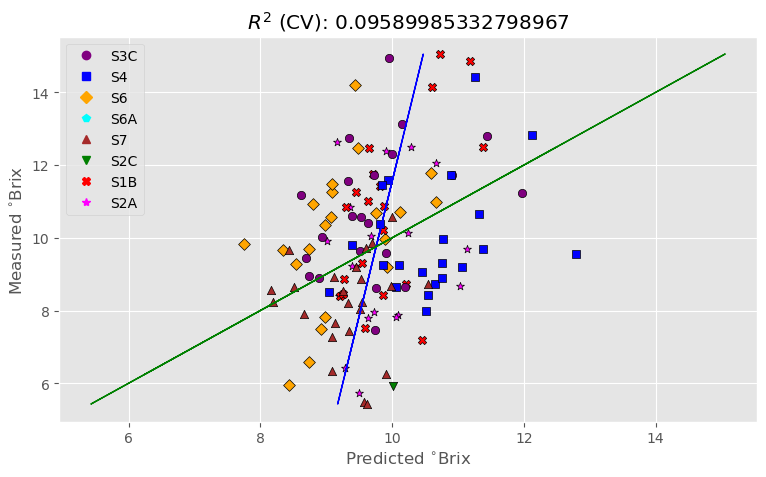

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  20
Wavelengths to be kept  23
Optimised MSEP  1.3875424970495285

[ 2.87979036  1.43461024  0.45666565  0.77115901  1.01369047  1.66569404
  0.48625586 -2.49940698 -0.22753033 -1.14609801 -1.42781197 -1.41422746
  1.32543509 -4.70498467 -0.56192238 -3.11900689 -1.32787933  0.66314525
 -2.60549531 -0.36252031  0.4685423  -2.74435874  3.03981108  4.36933303
  1.64527849  2.69805578  1.8369082   0.51195352  2.0942155   0.16812587
  1.17480396  1.12791231  1.06126724  2.94586683  1.07286594  2.87435605
  2.37952816 -0.95834319 -1.39338064  0.53787884 -0.91720405  3.41967679
  1.14554269 -0.6853694   1.94977517  0.56685638 -1.26127834 -0.4099081
  1.43417418  0.61965219  0.94284382  0.1678077   0.02659377  0.27127009
 -1.2910814  -0.6870434   0.81599976  0.52379295  0.26770405  0.79149301
 -0.30691387  0.59011019  0.43256172  0.16140724  0.24711549  0.15939168
  0.46291137  0.75661408 -0.5770435   0.22374087 -0.37087135 -1.10972035
 -1.36869011  0.41495

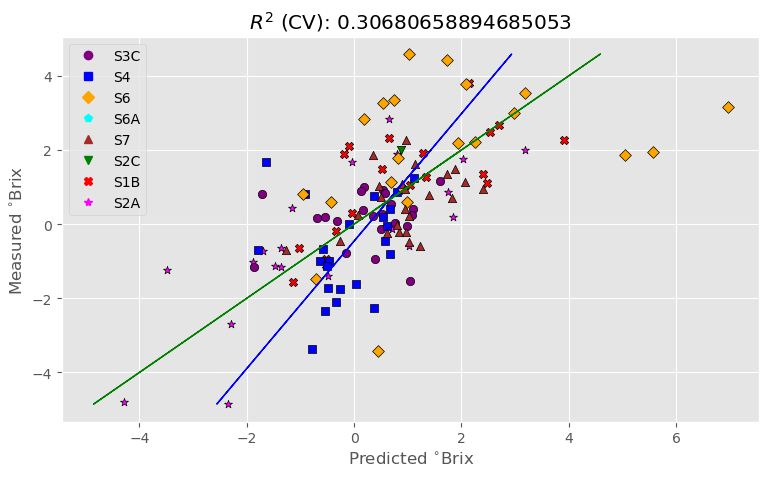

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  2
Wavelengths to be kept  69
Optimised MSEP  10.605852562657022

[46.54762618 48.90773753 52.37028749 52.8046629  52.5155552  44.65416949
 49.28243225 50.59039995 51.87002155 51.6905908  46.87817626 50.25359969
 46.80322982 51.51992607 43.85577213 55.9670355  51.82964707 41.93177036
 48.96471691 53.52147148 49.91446033 47.81591273 54.80627458 53.86012617
 52.84445689 47.50168919 51.36942064 50.92123397 49.47221301 43.02598484
 42.20758212 48.58446992 46.39673649 38.43065427 47.28979316 46.89127592
 48.64771563 46.65945922 48.66550465 41.69303753 48.00645686 52.01955377
 49.58566328 50.50491025 43.47600349 43.98619722 42.63343043 35.50200519
 45.91324723 52.65203149 45.81474015 52.86525149 45.72357092 49.26477465
 48.09933603 44.63872688 45.99502783 49.37039097 47.90722039 52.66011763
 45.32169966 40.37509298 47.52160215 53.26310715 47.56883287 46.61065009
 40.76567538 48.41176573 34.84503235 42.86004233 42.74838558 44.56826366
 40.72883066 44.96690

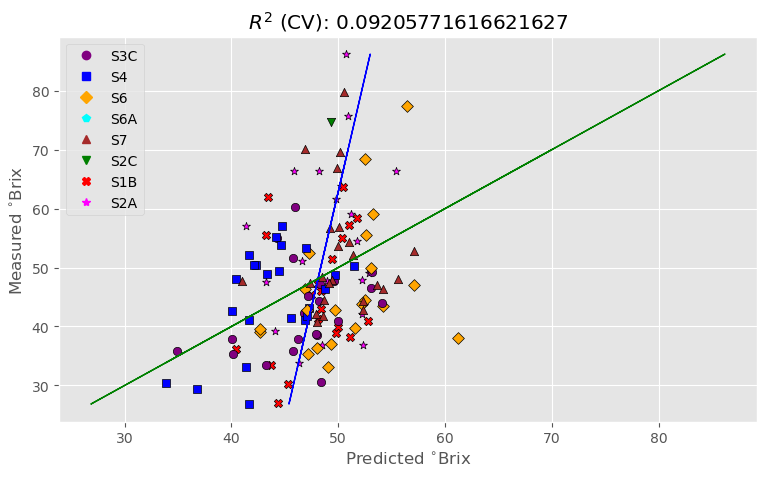

In [17]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  15
Wavelengths to be kept  20
Optimised MSEP  29.665307219625973

[447.88317541 505.55652049 477.37392408 482.90517678 455.43998533
 480.06422738 499.0105692  483.63775374 459.23938103 493.41400487
 524.05021643 478.86243604 492.32034276 484.83843958 477.33461337
 489.1019467  478.61077281 481.44716703 520.56906066 470.75420213
 423.1619628  479.50131622 434.03624979 454.27392945 459.91986358
 457.4708445  457.44746697 454.49192889 466.4636897  420.54160454
 428.19850464 433.22798246 440.17580478 423.00035188 497.84982855
 483.29582989 464.6608477  484.17799712 486.94130527 476.29695559
 479.79483854 453.80020971 473.89067466 465.21422251 497.11340328
 465.01335246 426.61260333 438.40455141 450.4619465  452.77229602
 432.97962301 454.44618358 464.58606601 441.17992773 449.77488463
 484.29230378 446.80276488 439.97530513 455.56126908 454.80380588
 458.2381255  441.55171735 437.62650507 463.45583441 455.43384874
 446.62690114 424.99296565 437.2731467

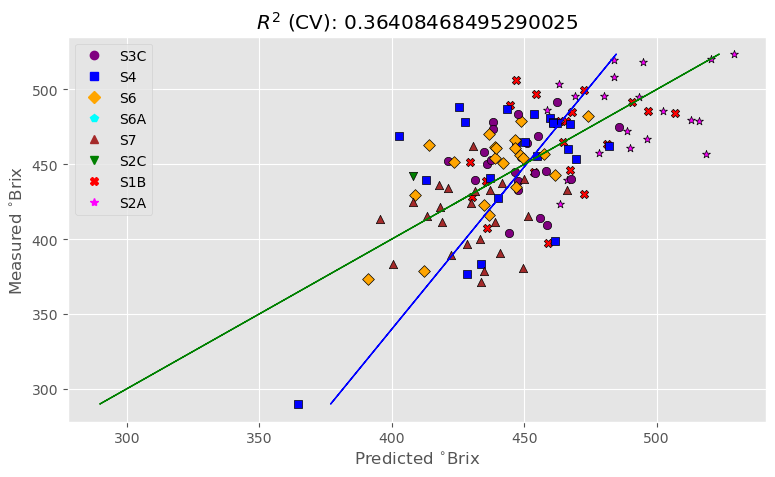

In [18]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [24]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\root_trait_RD13C.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_all plants.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground\root_trait_RD13C.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1


In [1]:
import pandas as pd
import glob
import os

# ===== paths =====
base_file = r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground\root_trait_RTD.csv"
join_folder = r"D:\wenqu\2024_data\PFT\pft_join"

# ===== read the base (LEFT table) =====
df_base = pd.read_csv(base_file)

# ===== find all csv files to join =====
join_files = glob.glob(os.path.join(join_folder, "*.csv"))

print(f"Found {len(join_files)} files to join.")

# ===== columns used to join (EDIT if needed) =====
keys = ["site"]   # change to ["QuadratID","Year","Site"] if needed

# ===== loop and join each file =====
df_final = df_base.copy()

for f in join_files:
    print(f"Joining: {os.path.basename(f)}")

    df_join = pd.read_csv(f)

    # left join
    df_final = df_final.merge(df_join, on=keys, how="left")

# ===== replace missing values with 0 =====
df_final = df_final.fillna(0)

# ===== save result =====
out_file = r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RTD.csv"
df_final.to_csv(out_file, index=False)

print("All files joined successfully.")
print("Saved to:", out_file)

Found 5 files to join.
Joining: DS.csv
Joining: ES.csv
Joining: F.csv
Joining: G.csv
Joining: M.csv
All files joined successfully.
Saved to: E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RTD.csv
